In [ ]:
from pathlib import Path
from scipy.io import loadmat
import sys
import os

# Robust path finding for data.mat
current_path = Path.cwd()
possible_data_paths = [
    current_path / 'data' / 'data.mat',
    current_path.parent / 'data' / 'data.mat',
    current_path.parent.parent / 'data' / 'data.mat',
    # Fallback absolute path
    Path('/home/luky/skola/KalmanNet-for-state-estimation/data/data.mat')
]

dataset_path = None
for p in possible_data_paths:
    if p.exists():
        dataset_path = p
        break

if dataset_path is None or not dataset_path.exists():
    print("Warning: data.mat not found automatically.")
    dataset_path = Path('data/data.mat')

print(f"Dataset path: {dataset_path}")

# Add project root to sys.path (2 levels up from debug/test)
notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
print(f"Project root added: {project_root}")

mat_data = loadmat(dataset_path)
print(mat_data.keys())


In [2]:
import torch
import matplotlib.pyplot as plt
from utils import trainer
from utils import utils
from Systems import DynamicSystem
import Filters
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from scipy.io import loadmat
from scipy.interpolate import RegularGridInterpolator
import random

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

device: cuda


In [3]:
mat_data = loadmat(dataset_path)

souradniceX_mapa = mat_data['souradniceX']
souradniceY_mapa = mat_data['souradniceY']
souradniceZ_mapa = mat_data['souradniceZ']
souradniceGNSS = mat_data['souradniceGNSS'] 
x_axis_unique = souradniceX_mapa[0, :]
y_axis_unique = souradniceY_mapa[:, 0]

print(f"Dimensions of 1D X axis: {x_axis_unique.shape}")
print(f"Dimensions of 1D Y axis: {y_axis_unique.shape}")
print(f"Dimensions of 2D elevation data Z: {souradniceZ_mapa.shape}")

terMap_interpolator = RegularGridInterpolator(
    (y_axis_unique, x_axis_unique),
    souradniceZ_mapa,
    bounds_error=False, 
    fill_value=np.nan
)

def terMap(px, py):
    # Query bilinear interpolation over the terrain map
    points_to_query = np.column_stack((py, px))
    return terMap_interpolator(points_to_query)

Dimensions of 1D X axis: (2500,)
Dimensions of 1D Y axis: (2500,)
Dimensions of 2D elevation data Z: (2500, 2500)


In [4]:
import torch
from Systems import DynamicSystemTAN

state_dim = 4
obs_dim = 3
dT = 1
q = 9.057863

F = torch.tensor([[1.0, 0.0, dT, 0.0],
                   [0.0, 1.0, 0.0, dT],
                   [0.0, 0.0, 1.0, 0.0],
                   [0.0, 0.0, 0.0, 1.0]])

Q = q* torch.tensor([[dT**3/3, 0.0, dT**2/2, 0.0],
                   [0.0, dT**3/3, 0.0, dT**2/2],
                   [dT**2/2, 0.0, dT, 0.0],
                   [0.0, dT**2/2, 0.0, dT]])
R = torch.tensor([[5.0**2, 0.0, 0.0],
                   [0.0, 1.0**2, 0.0],
                   [0.0, 0.0, 1.0**2]])

initial_velocity_np = souradniceGNSS[:2, 1] - souradniceGNSS[:2, 0]
# initial_velocity_np = torch.from_numpy()
initial_velocity = torch.from_numpy(np.array([0,0]))

initial_position = torch.from_numpy(souradniceGNSS[:2, 0])
x_0 = torch.cat([
    initial_position,
    initial_velocity
]).float()
print(x_0)

P_0 = torch.tensor([[25.0, 0.0, 0.0, 0.0],
                    [0.0, 25.0, 0.0, 0.0],
                    [0.0, 0.0, 0.5, 0.0],
                    [0.0, 0.0, 0.0, 0.5]])
import torch.nn.functional as func

def h_nl_differentiable(x: torch.Tensor, map_tensor, x_min, x_max, y_min, y_max) -> torch.Tensor:
    batch_size = x.shape[0]

    px = x[:, 0]
    py = x[:, 1]

    px_norm = 2.0 * (px - x_min) / (x_max - x_min) - 1.0
    py_norm = 2.0 * (py - y_min) / (y_max - y_min) - 1.0

    sampling_grid = torch.stack((px_norm, py_norm), dim=1).view(batch_size, 1, 1, 2)

    vyska_terenu_batch = func.grid_sample(
        map_tensor.expand(batch_size, -1, -1, -1),
        sampling_grid, 
        mode='bilinear', 
        padding_mode='border',
        align_corners=True
    )

    vyska_terenu = vyska_terenu_batch.view(batch_size)

    eps = 1e-12
    vx_w, vy_w = x[:, 2], x[:, 3]

    result = torch.stack([vyska_terenu, vx_w, vy_w], dim=1)

    return result

x_axis_unique = souradniceX_mapa[0, :]
y_axis_unique = souradniceY_mapa[:, 0]
terMap_tensor = torch.from_numpy(souradniceZ_mapa).float().unsqueeze(0).unsqueeze(0).to(device)
x_min, x_max = x_axis_unique.min(), x_axis_unique.max()
y_min, y_max = y_axis_unique.min(), y_axis_unique.max()

h_wrapper = lambda x: h_nl_differentiable(
    x, 
    map_tensor=terMap_tensor, 
    x_min=x_min, 
    x_max=x_max, 
    y_min=y_min, 
    y_max=y_max
)

system_model = DynamicSystemTAN(
    state_dim=state_dim,
    obs_dim=obs_dim,
    Q=Q.float(),
    R=R.float(),
    Ex0=x_0.float(),
    P0=P_0.float(),
    F=F.float(),
    h=h_wrapper,
    x_axis_unique=x_axis_unique, 
    y_axis_unique=y_axis_unique,
    device=device
)

tensor([1487547.1250, 6395520.5000,       0.0000,       0.0000])
INFO: DynamicSystemTAN inicializován s hranicemi mapy:
  X: [1476611.42, 1489541.47]
  Y: [6384032.63, 6400441.34]


In [5]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from utils import utils
import torch
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import os
import random
from copy import deepcopy
from state_NN_models import TAN
from utils import trainer 

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)


In [6]:
import torch
from torch.utils.data import TensorDataset, DataLoader
import os
from utils import trainer

class NavigationDataManager:
    def __init__(self, data_dir):
        self.data_dir = data_dir
        
    def get_dataloader(self, seq_len, split='train', shuffle=True, batch_size=32):
        path = os.path.join(self.data_dir, f'len_{seq_len}', f'{split}.pt')
        
        if not os.path.exists(path):
            raise FileNotFoundError(f"❌ Dataset nenalezen: {path}")
            
        data = torch.load(path)
        x = data['x'] 
        y = data['y'] 

        dataset = TensorDataset(x, y)
        
        return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

DATA_DIR = './generated_data_synthetic_controlled-extended-trajectories'

data_manager = NavigationDataManager(DATA_DIR)

curriculum_schedule = [
    {
        'phase_id': 1,
        'seq_len': 10,          
        'epochs': 500,           
        'lr': 1e-3, 
        'batch_size': 256
    },

    {
        'phase_id': 2,
        'seq_len': 100, 
        'epochs': 300, 
        'lr': 5e-4,             
        'batch_size': 128
    },
    {
        'phase_id': 4,
        'seq_len': 300,         
        'epochs': 300, 
        'lr':1e-4,             
        'batch_size': 128
    },
    {
        'phase_id': 5,
        'seq_len': 500,         
        'epochs': 300, 
        'lr':1e-4,             
        'batch_size': 128
    }
]

datasets_cache = {} 

for phase in curriculum_schedule:
    seq_len = phase['seq_len']
    bs = phase['batch_size']
    
    print(f"📥 Načítám Fázi {phase['phase_id']}: Seq={seq_len} | Batch={bs} ...")
    
    try:
        train_loader = data_manager.get_dataloader(seq_len=seq_len, split='train', shuffle=True, batch_size=bs)
        val_loader = data_manager.get_dataloader(seq_len=seq_len, split='val', shuffle=False, batch_size=bs)
        
        datasets_cache[phase['phase_id']] = (train_loader, val_loader)

        x_ex, y_ex = next(iter(train_loader))
     
    except FileNotFoundError as e:
        print(f"   ⚠️ error: {e}")


📥 Načítám Fázi 1: Seq=10 | Batch=256 ...
📥 Načítám Fázi 2: Seq=100 | Batch=128 ...
📥 Načítám Fázi 4: Seq=300 | Batch=128 ...
📥 Načítám Fázi 5: Seq=500 | Batch=128 ...


In [7]:
from state_NN_models import TAN

state_knet2 = TAN.StateKalmanNetTAN(
        system_model=system_model, 
        device=device,
        hidden_size_multiplier=10,       
        output_layer_multiplier=4,
        num_gru_layers=1,
        gru_hidden_dim_multiplier=8      
).to(device)


for phase in curriculum_schedule:
    phase_id = phase['phase_id']
    seq_len = phase['seq_len']
    
    print(f"\n--- PHASE {phase_id}: SeqLen {seq_len} ---")

    train_loader, val_loader = datasets_cache[phase_id]

    common_args = {
        'model': state_knet2,
        'train_loader': train_loader,
        'val_loader': val_loader,
        'device': device,
        'epochs': phase['epochs'],
        'lr': phase['lr'],
    }

    if seq_len <= 20:
        print("-> Using Standard Training (with Init Noise)")
        trainer.train_state_KalmanNetTAN(
            **common_args,
            optimizer_type=torch.optim.AdamW,
            weight_decay=1e-2,
            clip_grad=1.0,
            early_stopping_patience=100
        )
    elif seq_len == 100:
        print(f"-> Using TBPTT Sliding Window (k=40, w=20)")
        trainer.train_state_KalmanNet_sliding_windowTAN(
            **common_args,
            weight_decay_=1e-2,
            early_stopping_patience=50,
            tbptt_k=20,
            tbptt_w=40,
            optimizer_=torch.optim.AdamW,
            clip_grad=0.5,
            criterion_=nn.SmoothL1Loss(beta=1.0)
        )
        
    else: 
        print(f"-> Using TBPTT Sliding Window (k=50, w=20)")
        trainer.train_state_KalmanNet_sliding_windowTAN(
            **common_args,
            weight_decay_=1e-2,
            early_stopping_patience=50,
            tbptt_k=50,   
            tbptt_w=100,   
            optimizer_=torch.optim.AdamW,
            clip_grad=0.5,
            criterion_=nn.SmoothL1Loss(beta=1.0)
        )

DEBUG: Layer 'output_final_linear.0' initialized near zero (Start K=0).

--- PHASE 1: SeqLen 10 ---
-> Using Standard Training (with Init Noise)
Start training on cuda...
Epoch [1/500] | Train Loss: 72.9795 | Val Loss: 10.6980 -> New Best!
Epoch [2/500] | Train Loss: 8.2633 | Val Loss: 6.5533 -> New Best!
Epoch [3/500] | Train Loss: 5.9770 | Val Loss: 5.0605 -> New Best!
Epoch [4/500] | Train Loss: 4.9819 | Val Loss: 4.6046 -> New Best!
Epoch [5/500] | Train Loss: 4.8364 | Val Loss: 4.5485 | PosMSE: 7.9, VelMSE: 1.8 -> New Best!
Epoch [6/500] | Train Loss: 4.6994 | Val Loss: 4.4413 -> New Best!
Epoch [8/500] | Train Loss: 4.5736 | Val Loss: 4.4311 -> New Best!
Epoch [10/500] | Train Loss: 4.5131 | Val Loss: 4.5218 | PosMSE: 7.3, VelMSE: 1.7
Epoch [15/500] | Train Loss: 4.3237 | Val Loss: 4.6705 | PosMSE: 6.9, VelMSE: 1.7
Epoch [20/500] | Train Loss: 3.8800 | Val Loss: 4.7444 | PosMSE: 6.1, VelMSE: 1.7
Epoch [25/500] | Train Loss: 3.3314 | Val Loss: 5.2656 | PosMSE: 5.0, VelMSE: 1.7
Epo

In [8]:
if False:
    # save model.
    save_path = f'knet_curriculum_model28_vyrovnane_s_UKF24.pth'
    torch.save(state_knet2.state_dict(), save_path)
    print(f"Model saved to '{save_path}'.")

=== ANALÝZA DATASETU: ./generated_data_synthetic_controlled-extended-trajectories/len_500/train.pt ===
Tvar X (Stavy): torch.Size([2000, 500, 4])
Tvar Y (Měření): torch.Size([2000, 500, 3])

--- 1. KONTROLA NaN a Inf ---
Počet NaN v X: 0
Počet Inf v X: 0
Počet NaN v Y: 0
Počet Inf v Y: 0

--- 2. FYZIKÁLNÍ LIMITY (Min / Max) ---
Poloha X:  Min = 1476626.62 m, Max = 1489535.12 m
Poloha Y:  Min = 6384033.00 m, Max = 6400434.00 m
Rychlost X: Min = -42.83 m/s, Max = 43.05 m/s
Rychlost Y: Min = -42.99 m/s, Max = 43.43 m/s

Měření Výšky (hB): Min = 288.35 m, Max = 502.87 m

--- 3. KONTROLA TELEPORTACE (Max delta polohy) ---
Maximální vzdálenost ujetá za 1 krok: 43.91 m

--- 4. VIZUALIZACE DISTRIBUCE ---


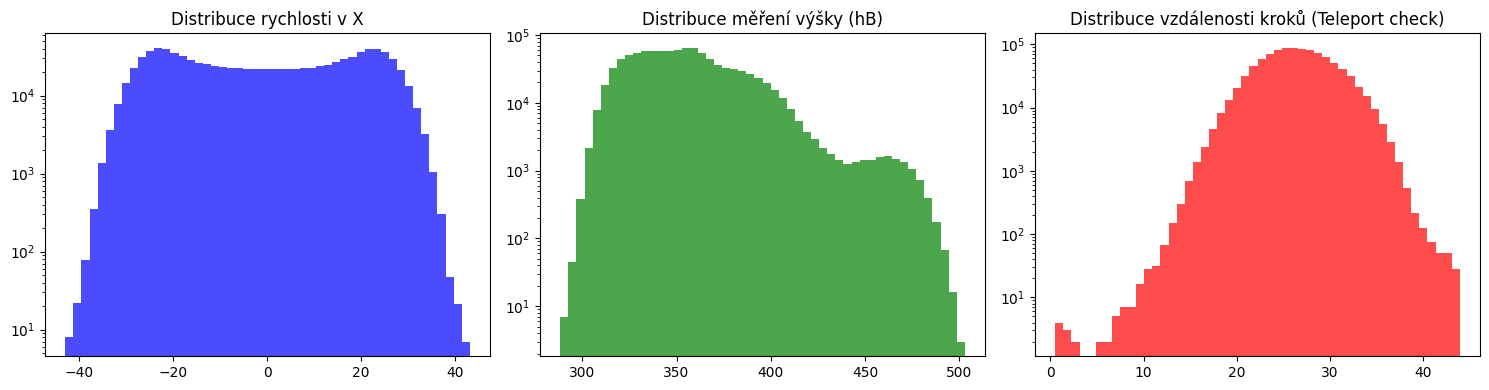

In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def analyze_dataset_outliers(file_path):
    print(f"=== ANALÝZA DATASETU: {file_path} ===")
    try:
        data = torch.load(file_path)
    except FileNotFoundError:
        print(f"Soubor {file_path} nebyl nalezen.")
        return

    X = data['x']  # Ground truth [N, Seq, 4] -> (x, y, vx, vy)
    Y = data['y']  # Measurements [N, Seq, 3] -> (hB, vx_w, vy_w)
    
    print(f"Tvar X (Stavy): {X.shape}")
    print(f"Tvar Y (Měření): {Y.shape}")
    
    # 1. Kontrola na NaN a nekonečna
    print("\n--- 1. KONTROLA NaN a Inf ---")
    print(f"Počet NaN v X: {torch.isnan(X).sum().item()}")
    print(f"Počet Inf v X: {torch.isinf(X).sum().item()}")
    print(f"Počet NaN v Y: {torch.isnan(Y).sum().item()}")
    print(f"Počet Inf v Y: {torch.isinf(Y).sum().item()}")

    # 2. Fyzikální rozsahy (Min a Max)
    print("\n--- 2. FYZIKÁLNÍ LIMITY (Min / Max) ---")
    x_pos, y_pos = X[:, :, 0], X[:, :, 1]
    x_vel, y_vel = X[:, :, 2], X[:, :, 3]
    
    print(f"Poloha X:  Min = {x_pos.min().item():.2f} m, Max = {x_pos.max().item():.2f} m")
    print(f"Poloha Y:  Min = {y_pos.min().item():.2f} m, Max = {y_pos.max().item():.2f} m")
    print(f"Rychlost X: Min = {x_vel.min().item():.2f} m/s, Max = {x_vel.max().item():.2f} m/s")
    print(f"Rychlost Y: Min = {y_vel.min().item():.2f} m/s, Max = {y_vel.max().item():.2f} m/s")
    
    y_hB = Y[:, :, 0]
    print(f"\nMěření Výšky (hB): Min = {y_hB.min().item():.2f} m, Max = {y_hB.max().item():.2f} m")

    # 3. Kontrola "Teleportace" (Max skok mezi kroky)
    print("\n--- 3. KONTROLA TELEPORTACE (Max delta polohy) ---")
    # Spočítáme rozdíl polohy mezi časem t a t-1
    pos_diff = torch.diff(X[:, :, :2], dim=1) 
    step_distances = torch.norm(pos_diff, dim=2) # Euklidovská vzdálenost skoku
    
    max_jump = step_distances.max().item()
    print(f"Maximální vzdálenost ujetá za 1 krok: {max_jump:.2f} m")
    if max_jump > 50.0:  # Uprav podle své vzorkovací frekvence a max rychlosti
        print("⚠️ POZOR: Detekován extrémně velký skok v poloze! Zkontroluj simulátor.")

    # 4. Vizualizace distribuce (Detekce nenápadných outlierů)
    print("\n--- 4. VIZUALIZACE DISTRIBUCE ---")
    fig, axs = plt.subplots(1, 3, figsize=(15, 4))
    
    # Histogram rychlostí
    axs[0].hist(x_vel.flatten().numpy(), bins=50, color='blue', alpha=0.7)
    axs[0].set_title('Distribuce rychlosti v X')
    axs[0].set_yscale('log') # Log scale zvýrazní osamocené outliery
    
    # Histogram měření výšky
    axs[1].hist(y_hB.flatten().numpy(), bins=50, color='green', alpha=0.7)
    axs[1].set_title('Distribuce měření výšky (hB)')
    axs[1].set_yscale('log')
    
    # Histogram velikosti kroků
    axs[2].hist(step_distances.flatten().numpy(), bins=50, color='red', alpha=0.7)
    axs[2].set_title('Distribuce vzdálenosti kroků (Teleport check)')
    axs[2].set_yscale('log')
    
    plt.tight_layout()
    plt.show()

# Spusť to na datasetu s nejdelšími sekvencemi (kde se chyby kumulují nejvíce)
analyze_dataset_outliers('./generated_data_synthetic_controlled-extended-trajectories/len_500/train.pt')

# Synthetic trajectory test

In [10]:
import torch

class AuxiliaryParticleFilterTAN:
    """
    100% PyTorch (GPU) Vektorizovaný Auxiliary Particle Filter (APF).
    Žádné CPU ping-pongy, žádné numpy/scipy uvnitř inferenční smyčky.
    """
    
    def __init__(self, system_model, num_particles=1000):
        self.device = system_model.Q.device
        self.f = system_model.f
        self.h = system_model.h
        self.N = num_particles
        self.state_dim = system_model.Q.shape[0]
        
        # Uchováme matice nativně v PyTorchu na GPU
        self.Ex0 = system_model.Ex0.view(-1)
        self.P0 = system_model.P0
        self.Q = system_model.Q
        self.R = system_model.R
        
        # Předpočítáme Choleského dekompozici pro bleskové generování šumu na GPU
        self.L_Q = torch.linalg.cholesky(self.Q + torch.eye(self.state_dim, device=self.device) * 1e-6)
        
    def _compute_log_likelihood_vectorized(self, particles, z, R):
        """
        Vrátí log(p(z|x)) pro všechny částice najednou čistě na GPU.
        """
        mask = ~torch.isnan(z)
        if not mask.any():
            return torch.zeros(self.N, device=self.device)

        z_valid = z[mask]
        
        # Submatice pro R
        # torch.ix_ neexistuje úplně stejně jako v numpy, vyřešíme přes maskování řádků a sloupců
        R_valid = R[mask][:, mask]

        # Predikce měření (h) [N, meas_dim]
        expected_measurements = self.h(particles)
        expected_valid = expected_measurements[:, mask]

        # Výpočet Log-PDF přes PyTorch distribuce přímo na GPU
        try:
            # MultivariateNormal očekává [N, D] tensor hodnot a vyhodnotí je proti [D] průměru
            dist = torch.distributions.MultivariateNormal(z_valid, R_valid)
            log_lik = dist.log_prob(expected_valid)
        except ValueError:
            # Pokud dojde k chybě (např. singulární matice)
            return torch.full((self.N,), float('-inf'), device=self.device)
            
        return log_lik

    def _normalize_log_weights(self, log_weights):
        """Stabilní softmax čistě v PyTorchu."""
        max_log = torch.max(log_weights)
        if torch.isinf(max_log):
            return torch.full((self.N,), 1.0 / self.N, device=self.device)
            
        weights_unnorm = torch.exp(log_weights - max_log)
        weights = weights_unnorm / torch.sum(weights_unnorm)
        return weights

    def _systematic_resample(self, weights):
        """
        Bleskový vektorizovaný systematic resampling (bez for/while cyklu!).
        """
        # Vygenerujeme jeden náhodný posun a vytvoříme N ekvidistantních bodů
        u = (torch.arange(self.N, device=self.device, dtype=torch.float) + torch.rand(1, device=self.device)) / self.N
        
        # Kumulativní součet vah
        cumsum = torch.cumsum(weights, dim=0)
        
        # Zabráníme numerickým chybám na konci
        cumsum[-1] = 1.0 
        
        # Bleskové GPU vyhledání indexů (ekvivalent while cyklu)
        indexes = torch.searchsorted(cumsum, u)
        
        # Bezpečnostní pojistka proti out-of-bounds
        return torch.clamp(indexes, 0, self.N - 1)

    def get_estimate(self, particles, weights):
        # 1. Průměr: Vážený součet částic (Sum přes dimenzi částic)
        # weights: [N], particles: [N, D]
        mean = torch.sum(particles * weights.unsqueeze(1), dim=0) # [D]
        
        # 2. Kovariance
        diff = particles - mean.unsqueeze(0) # [N, D]
        # (W * diff)^T @ diff -> [D, N] @ [N, D] = [D, D]
        cov = (weights.unsqueeze(1) * diff).T @ diff
        
        # === OPRAVA ANEES ===
        min_cov_val = 1e-3 
        cov = cov + torch.eye(self.state_dim, device=self.device) * min_cov_val
        
        return mean.view(self.state_dim, 1), cov
    
    def process_sequence(self, y_seq, u_sequence=None, Ex0=None, P0=None):
        # Necháme vše jako Tensor na GPU (odstraněno .cpu().numpy())
        seq_len = y_seq.shape[0]
        
        ex0_curr = Ex0.view(-1) if Ex0 is not None else self.Ex0
        p0_curr = P0 if P0 is not None else self.P0
        
        # Historie
        x_filtered_history = torch.zeros(seq_len, self.state_dim, device=self.device)
        P_filtered_history = torch.zeros(seq_len, self.state_dim, self.state_dim, device=self.device)
        
        # Inicializace (Cholesky generování na GPU)
        L_P0 = torch.linalg.cholesky(p0_curr + torch.eye(self.state_dim, device=self.device) * 1e-6)
        current_particles = ex0_curr + torch.randn(self.N, self.state_dim, device=self.device) @ L_P0.T
        
        current_weights = torch.full((self.N,), 1.0 / self.N, device=self.device)
        
        # Uložení počátečního stavu
        x_est, P_est = self.get_estimate(current_particles, current_weights)
        x_filtered_history[0] = x_est.squeeze()
        P_filtered_history[0] = P_est

        for k in range(1, seq_len):
            u_k = u_sequence[k] if u_sequence is not None else None
            y_k = y_seq[k]
            is_measurement_valid = not torch.all(torch.isnan(y_k))

            # --- APF FÁZE 1: Lookahead & Auxiliary Weights ---
            if u_k is not None:
                u_torch = u_k.view(1, -1).repeat(self.N, 1)
                mu_particles = self.f(current_particles, u_torch)
            else:
                mu_particles = self.f(current_particles)

            log_weights_prev = torch.log(current_weights + 1e-30)
            
            if is_measurement_valid:
                log_lik_aux = self._compute_log_likelihood_vectorized(mu_particles, y_k, self.R)
                log_weights_aux = log_weights_prev + log_lik_aux
            else:
                log_weights_aux = log_weights_prev
                
            weights_aux = self._normalize_log_weights(log_weights_aux)

            # --- APF FÁZE 2: Resampling ---
            parent_indices = self._systematic_resample(weights_aux)
            parents = current_particles[parent_indices]
            
            # --- APF FÁZE 3: Finální propagace ---
            if u_k is not None:
                u_torch_parents = u_k.view(1, -1).repeat(self.N, 1)
                pred_parents = self.f(parents, u_torch_parents)
            else:
                pred_parents = self.f(parents)
                
            # Přidání šumu Q pomocí GPU
            noise = torch.randn(self.N, self.state_dim, device=self.device) @ self.L_Q.T
            current_particles = pred_parents + noise

            # --- APF FÁZE 4: Korekce vah ---
            if is_measurement_valid:
                log_lik_final = self._compute_log_likelihood_vectorized(current_particles, y_k, self.R)
                log_lik_aux_parents = log_lik_aux[parent_indices]
                log_weights_new = log_lik_final - log_lik_aux_parents
            else:
                log_weights_new = torch.zeros(self.N, device=self.device)

            current_weights = self._normalize_log_weights(log_weights_new)
            
            # Odhad a uložení
            x_est, P_est = self.get_estimate(current_particles, current_weights)
            x_filtered_history[k] = x_est.squeeze()
            P_filtered_history[k] = P_est
            
        return {'x_filtered': x_filtered_history, 'P_filtered': P_filtered_history}

Evaluace:   0%|          | 0/10 [00:00<?, ?it/s]

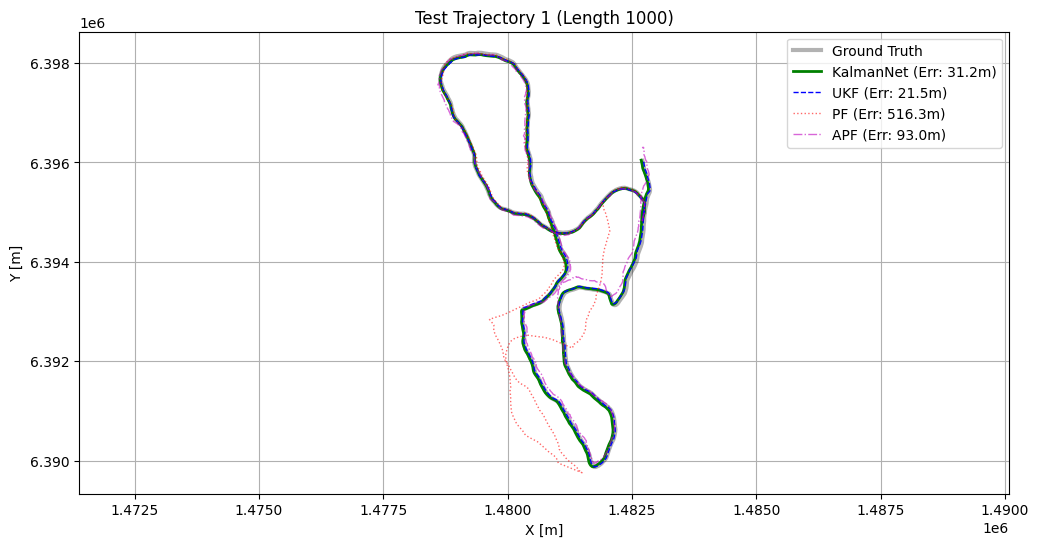

Evaluace:  10%|█         | 1/10 [02:08<19:17, 128.67s/it]

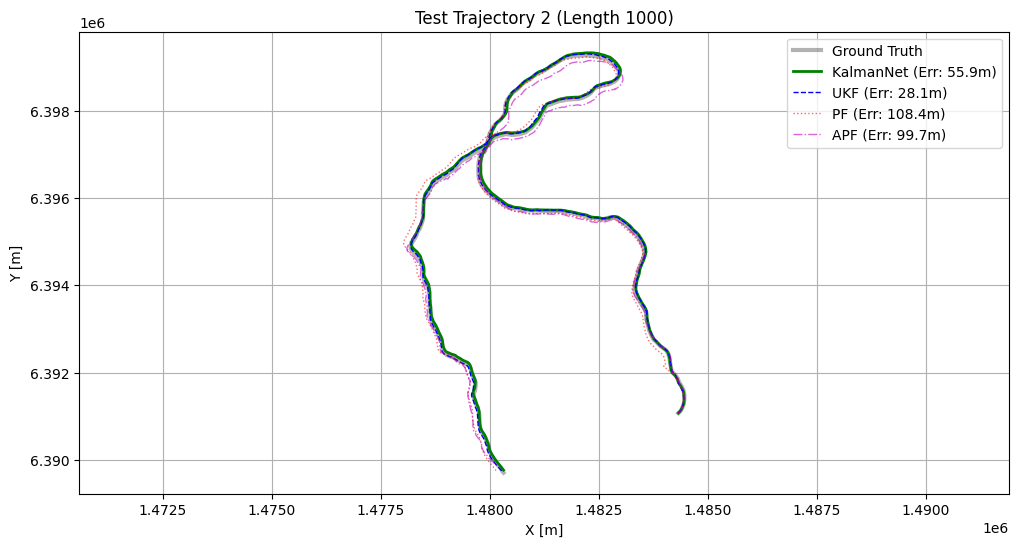

Evaluace:  20%|██        | 2/10 [03:26<13:08, 98.52s/it] 

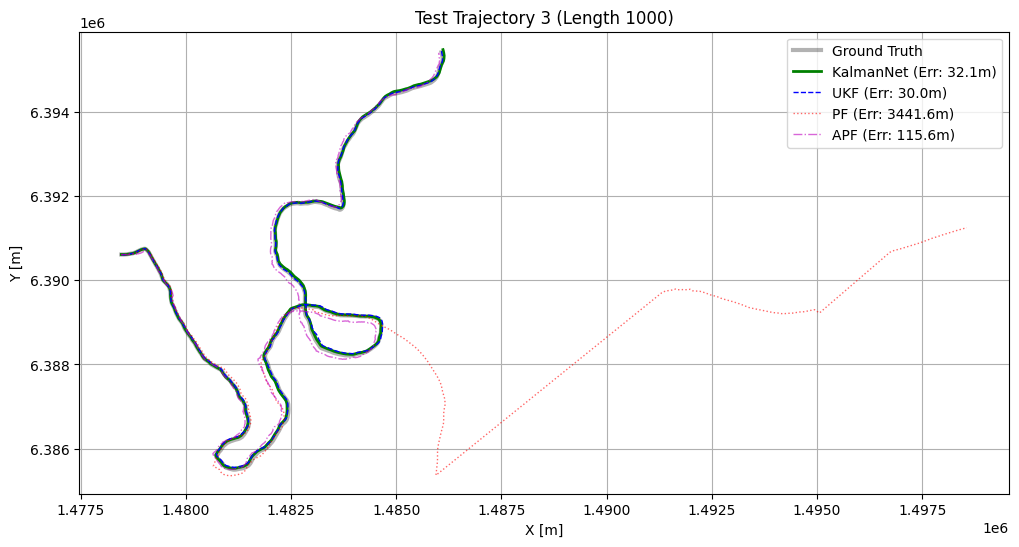

Evaluace:  30%|███       | 3/10 [04:39<10:09, 87.11s/it]

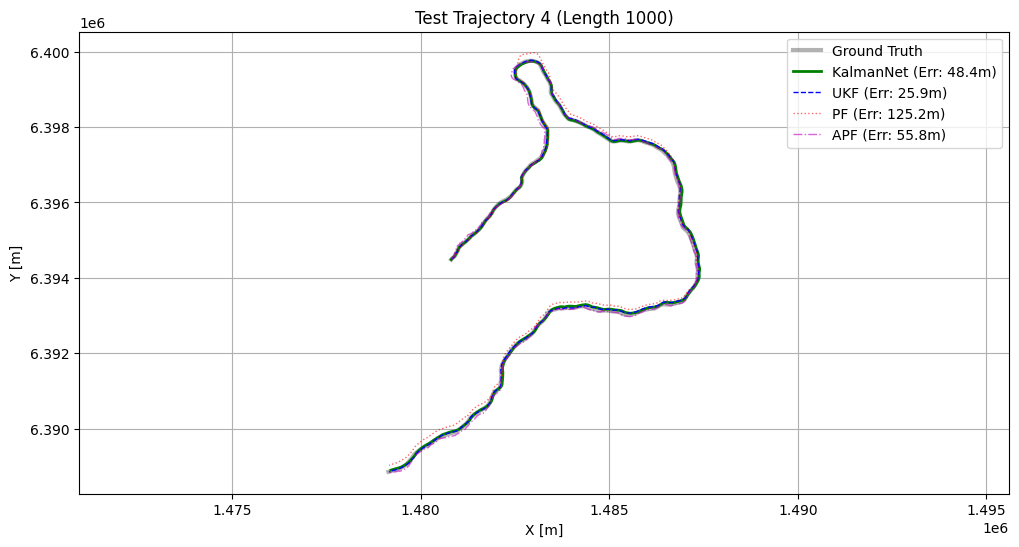

Evaluace:  40%|████      | 4/10 [05:52<08:09, 81.63s/it]

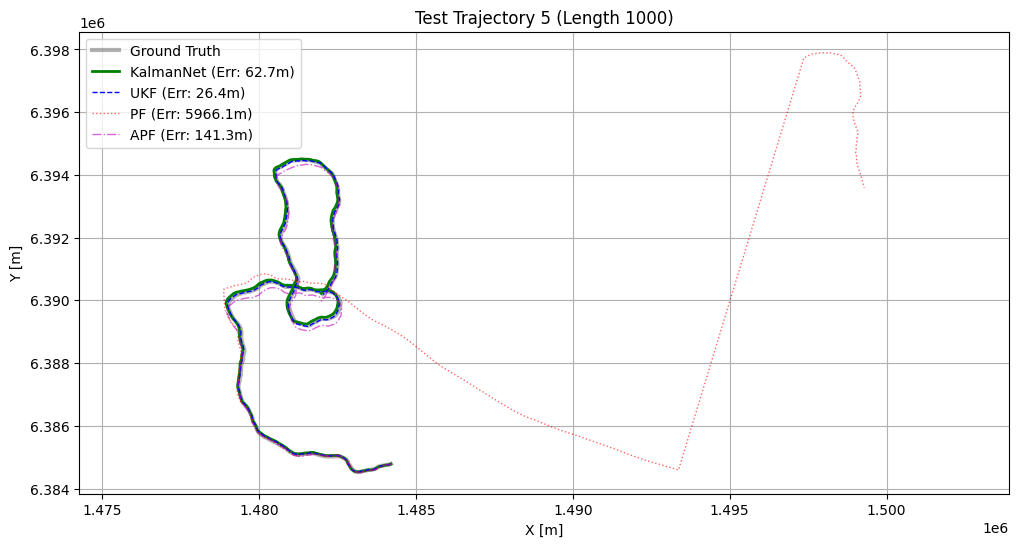

Evaluace:  50%|█████     | 5/10 [07:05<06:32, 78.55s/it]

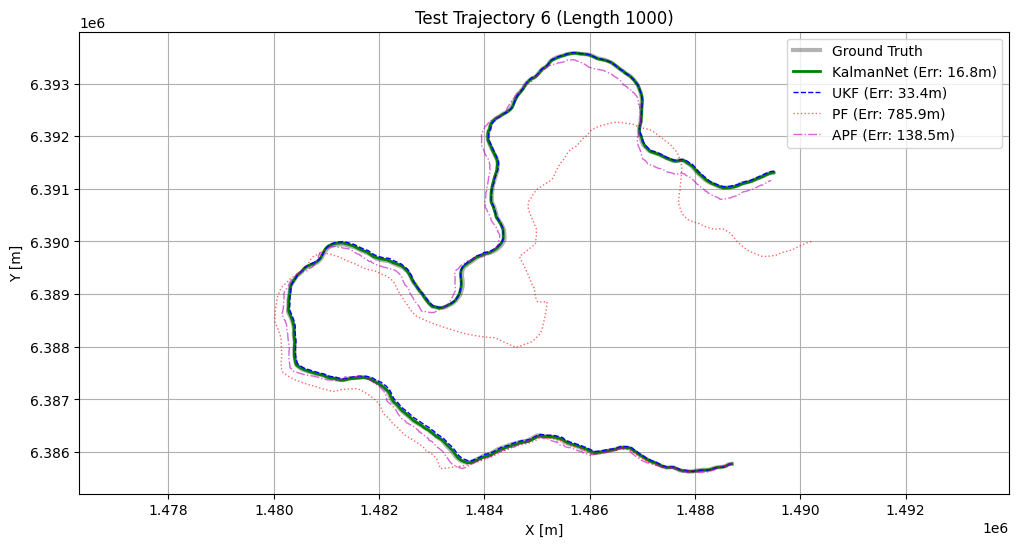

Evaluace:  60%|██████    | 6/10 [08:19<05:06, 76.70s/it]

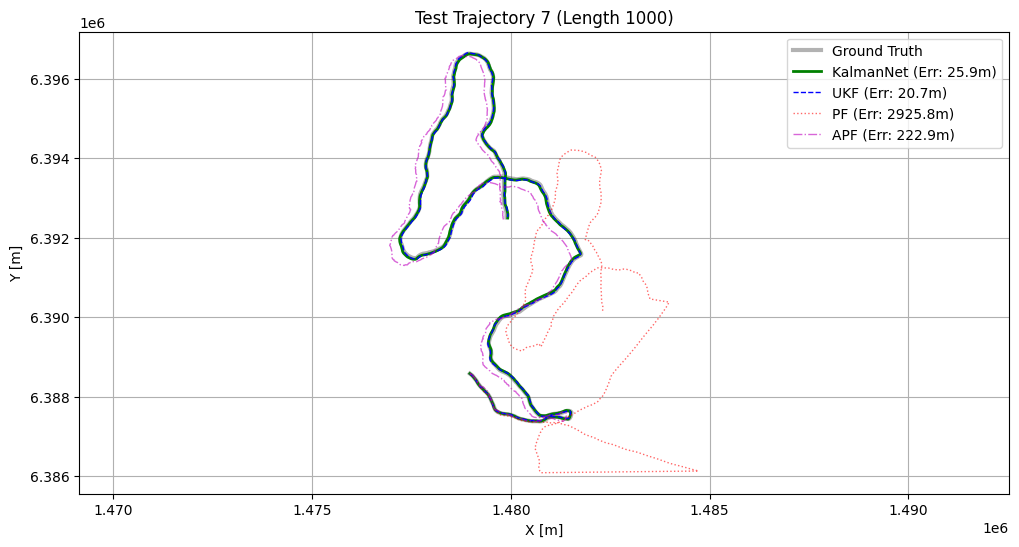

Evaluace:  70%|███████   | 7/10 [09:31<03:46, 75.46s/it]

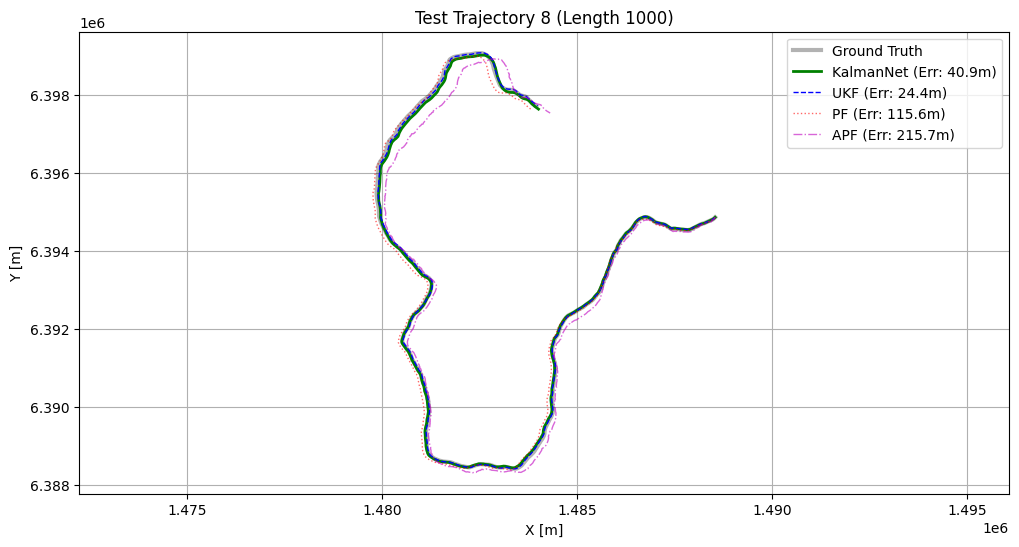

Evaluace:  80%|████████  | 8/10 [10:44<02:29, 74.50s/it]

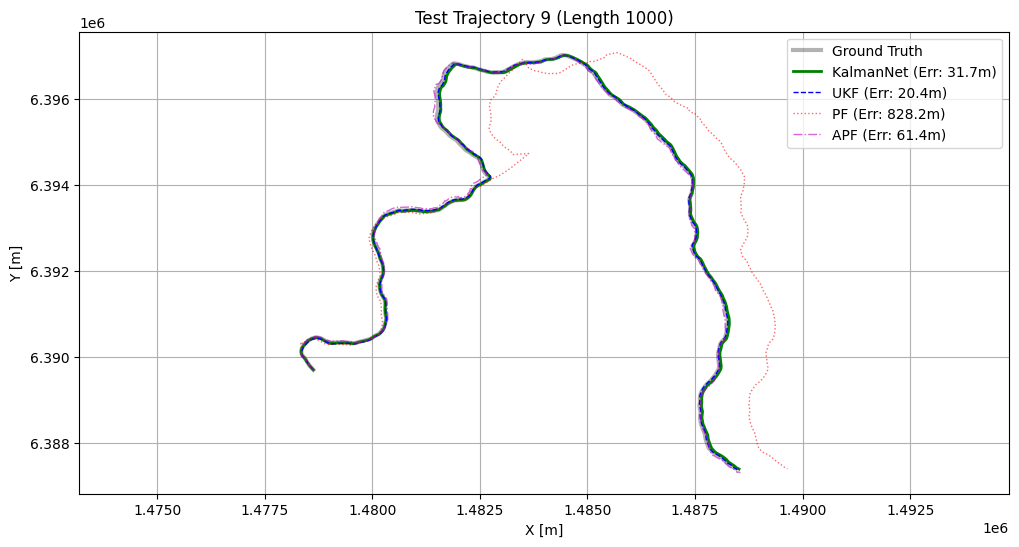

Evaluace:  90%|█████████ | 9/10 [11:57<01:14, 74.14s/it]

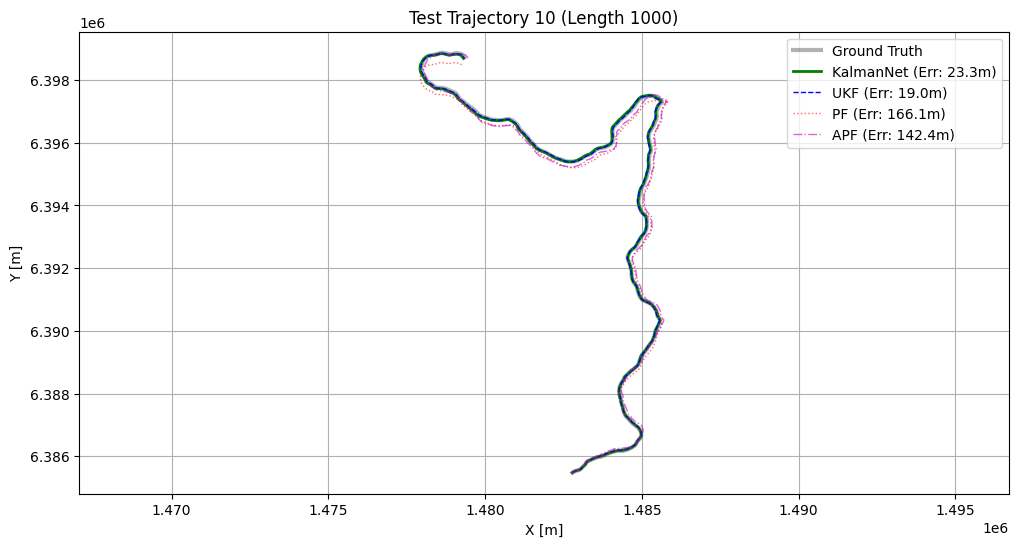

Evaluace: 100%|██████████| 10/10 [13:10<00:00, 79.05s/it]

   Run_ID  KNet_MSE  UKF_MSE        PF_MSE   APF_MSE  KNet_PosErr  UKF_PosErr  \
0       1  1,127.29   731.54    576,440.69 15,310.27        31.18       21.50   
1       2  3,451.29 1,015.89     14,542.38 12,798.75        55.89       28.09   
2       3  1,358.62 1,220.96 32,056,916.00 16,502.61        32.06       29.96   
3       4  2,968.89   993.49     20,871.21  3,838.33        48.35       25.86   
4       5  4,348.56   888.49 86,592,328.00 24,973.89        62.70       26.44   
5       6    374.57 1,334.68  1,067,260.25 22,334.13        16.82       33.42   
6       7    770.43   553.32 10,011,355.00 57,069.84        25.93       20.73   
7       8  2,526.86   827.04     14,627.51 61,124.04        40.93       24.39   
8       9  1,421.88   555.88    958,397.06  5,123.82        31.69       20.42   
9      10    719.24   487.75     33,696.63 22,187.59        23.32       19.03   

   PF_PosErr  APF_PosErr  
0     516.34       93.01  
1     108.41       99.73  
2   3,441.62      115.65  



C:\Users\PC1\AppData\Local\Temp\ipykernel_18988\2903493191.py:169: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([agg_pos["KNet"], agg_pos["UKF"], agg_pos["PF"], agg_pos["APF"]], labels=['KalmanNet', 'UKF', 'PF', 'APF'], patch_artist=True)


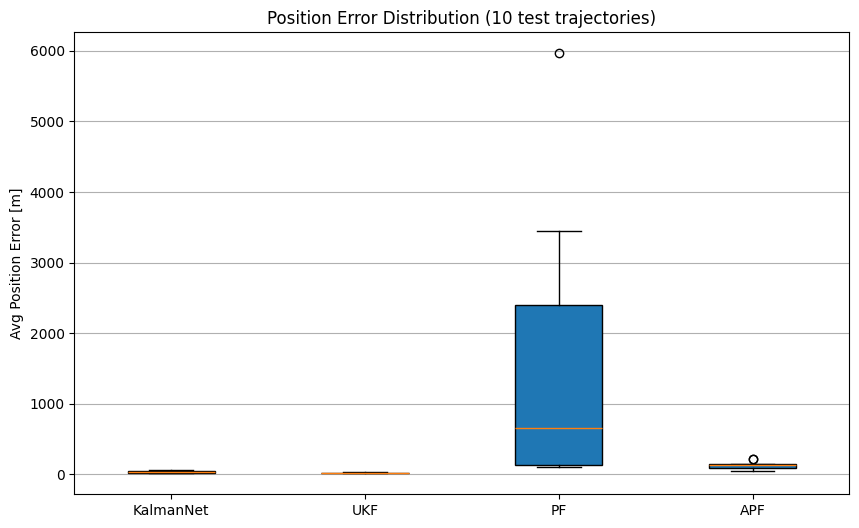

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import Filters
import os
from tqdm import tqdm
from Filters import TAN

TEST_DATA_PATH = './generated_data_synthetic_controlled-extended-trajectories/test_set/test.pt'
PLOT_PER_ITERATION = True 
MAX_TEST_SAMPLES = 10     


test_data = torch.load(TEST_DATA_PATH, map_location=device)
X_test_all = test_data['x']  # Ground Truth [N, Seq, 4]
Y_test_all = test_data['y']  # Measurements [N, Seq, 3]

n_samples = min(X_test_all.shape[0], MAX_TEST_SAMPLES)


detailed_results = []
agg_mse = {"KNet": [], "UKF": [], "PF": [], "APF": []}
agg_pos = {"KNet": [], "UKF": [], "PF": [], "APF": []}

state_knet2.eval()

for i in tqdm(range(n_samples), desc="Evaluace"):
    
    x_gt_tensor = X_test_all[i]      # [Seq, 4]
    y_obs_tensor = Y_test_all[i]     # [Seq, 3]
    
    x_gt = x_gt_tensor.cpu().numpy()
    seq_len = x_gt.shape[0]

    true_init_state = x_gt_tensor[0] # [4]

    with torch.no_grad():
        initial_state_batch = true_init_state.unsqueeze(0) # [1, 4]
        

        state_knet2.reset(batch_size=1, initial_state=initial_state_batch)
        
        knet_preds = []

        y_input_batch = y_obs_tensor.unsqueeze(0) # [1, Seq, 3]
        
        for t in range(1, seq_len):
            y_t = y_input_batch[:, t, :] # [1, 3]
            x_est = state_knet2.step(y_t)
            knet_preds.append(x_est)

        if len(knet_preds) > 0:
            knet_preds_tensor = torch.stack(knet_preds, dim=1) # [1, Seq-1, 4]
            full_knet_est = torch.cat([initial_state_batch.unsqueeze(1), knet_preds_tensor], dim=1)
        else:
            full_knet_est = initial_state_batch.unsqueeze(1)
            
        x_est_knet = full_knet_est.squeeze().cpu().numpy()
    
    # UKF
    ukf_ideal = TAN.UnscentedKalmanFilterTAN(system_model)
    ukf_res = ukf_ideal.process_sequence(
        y_seq=y_obs_tensor,
        Ex0=true_init_state, 
        P0=system_model.P0
    )
    x_est_ukf = ukf_res['x_filtered'].cpu().numpy()

    pf = TAN.ParticleFilterTAN(system_model, num_particles=10) 
    pf_res = pf.process_sequence(
        y_seq=y_obs_tensor,
        Ex0=true_init_state, 
        P0=system_model.P0
    )
    x_est_pf = pf_res['x_filtered'].cpu().numpy()

    # Auxiliary PF
    apf = AuxiliaryParticleFilterTAN(system_model, num_particles=200000) 
    apf_res = apf.process_sequence(
        y_seq=y_obs_tensor,
        Ex0=true_init_state, 
        P0=system_model.P0
    )
    x_est_apf = apf_res['x_filtered'].cpu().numpy()
    

    min_len = min(len(x_gt), len(x_est_knet), len(x_est_ukf))
    
    # KNet
    diff_knet = x_est_knet[:min_len] - x_gt[:min_len]
    mse_knet = np.mean(np.sum(diff_knet[:, :2]**2, axis=1))
    pos_err_knet = np.mean(np.sqrt(diff_knet[:, 0]**2 + diff_knet[:, 1]**2))
    
    # UKF
    diff_ukf = x_est_ukf[:min_len] - x_gt[:min_len]
    mse_ukf = np.mean(np.sum(diff_ukf[:, :2]**2, axis=1))
    pos_err_ukf = np.mean(np.sqrt(diff_ukf[:, 0]**2 + diff_ukf[:, 1]**2))
    
    # PF
    diff_pf = x_est_pf[:min_len] - x_gt[:min_len]
    mse_pf = np.mean(np.sum(diff_pf[:, :2]**2, axis=1))
    pos_err_pf = np.mean(np.sqrt(diff_pf[:, 0]**2 + diff_pf[:, 1]**2))

    # APF
    diff_apf = x_est_apf[:min_len] - x_gt[:min_len]
    mse_apf = np.mean(np.sum(diff_apf[:, :2]**2, axis=1))
    pos_err_apf = np.mean(np.sqrt(diff_apf[:, 0]**2 + diff_apf[:, 1]**2))
    
    agg_mse["KNet"].append(mse_knet)
    agg_pos["KNet"].append(pos_err_knet)
    agg_mse["UKF"].append(mse_ukf)
    agg_pos["UKF"].append(pos_err_ukf)
    agg_mse["PF"].append(mse_pf)
    agg_pos["PF"].append(pos_err_pf)
    agg_mse["APF"].append(mse_apf)
    agg_pos["APF"].append(pos_err_apf)

    detailed_results.append({
        "Run_ID": i + 1,
        "KNet_MSE": mse_knet,
        "UKF_MSE": mse_ukf,
        "PF_MSE": mse_pf,
        "KNet_PosErr": pos_err_knet,
        "UKF_PosErr": pos_err_ukf,
        "PF_PosErr": pos_err_pf,
        "APF_MSE": mse_apf,
        "APF_PosErr": pos_err_apf
    })
    

    if PLOT_PER_ITERATION:
        fig = plt.figure(figsize=(12, 6))
        plt.plot(x_gt[:, 0], x_gt[:, 1], 'k-', linewidth=3, alpha=0.3, label='Ground Truth')
        plt.plot(x_est_knet[:, 0], x_est_knet[:, 1], 'g-', linewidth=2, label=f'KalmanNet (Err: {pos_err_knet:.1f}m)')
        plt.plot(x_est_ukf[:, 0], x_est_ukf[:, 1], 'b--', linewidth=1, label=f'UKF (Err: {pos_err_ukf:.1f}m)')
        plt.plot(x_est_pf[:, 0], x_est_pf[:, 1], 'r:', linewidth=1, alpha=0.6, label=f'PF (Err: {pos_err_pf:.1f}m)')
        plt.plot(x_est_apf[:, 0], x_est_apf[:, 1], 'm-.', linewidth=1, alpha=0.6, label=f'APF (Err: {pos_err_apf:.1f}m)')
        plt.title(f"Test Trajectory {i+1} (Length {seq_len})")
        plt.xlabel("X [m]")
        plt.ylabel("Y [m]")
        plt.legend()
        plt.axis('equal')
        plt.grid(True)
        plt.show()

df_results = pd.DataFrame(detailed_results)
print("="*80)
pd.options.display.float_format = '{:,.2f}'.format
print(df_results[["Run_ID", "KNet_MSE", "UKF_MSE", "PF_MSE", "APF_MSE", "KNet_PosErr", "UKF_PosErr", "PF_PosErr", "APF_PosErr"]])


def get_stats(key):
    return np.mean(agg_mse[key]), np.std(agg_mse[key]), np.mean(agg_pos[key]), np.std(agg_pos[key])

knet_stats = get_stats("KNet")
ukf_stats = get_stats("UKF")
pf_stats = get_stats("PF")
apf_stats = get_stats("APF")
print(f"{'Model':<15} | {'MSE (Mean ± Std)':<25} | {'Pos Error (Mean ± Std)':<25}")
print("-" * 75)
print(f"{'KalmanNet':<15} | {knet_stats[0]:.1f} ± {knet_stats[1]:.1f} | {knet_stats[2]:.2f} ± {knet_stats[3]:.2f} m")
print(f"{'UKF':<15} | {ukf_stats[0]:.1f} ± {ukf_stats[1]:.1f} | {ukf_stats[2]:.2f} ± {ukf_stats[3]:.2f} m")
print(f"{'PF':<15} | {pf_stats[0]:.1f} ± {pf_stats[1]:.1f} | {pf_stats[2]:.2f} ± {pf_stats[3]:.2f} m")
print(f"{'APF':<15} | {apf_stats[0]:.1f} ± {apf_stats[1]:.1f} | {apf_stats[2]:.2f} ± {apf_stats[3]:.2f} m")
print("="*80)

plt.figure(figsize=(10, 6))
plt.boxplot([agg_pos["KNet"], agg_pos["UKF"], agg_pos["PF"], agg_pos["APF"]], labels=['KalmanNet', 'UKF', 'PF', 'APF'], patch_artist=True)
plt.title(f"Position Error Distribution ({n_samples} test trajectories)")
plt.ylabel("Avg Position Error [m]")
plt.grid(True, axis='y')
plt.show()